In [1]:
import re
with open('clinical.tsv') as f:
    header, *lines = f.readlines()
    data = {}
    for line in lines:
        cols = line.strip().split('\t')
        if cols[15] == 'Alive' and re.search(r'\d+', cols[47]): #cols[47] days_to_last_follow_up
            data.setdefault(cols[1], f'{int(cols[47]) // 30}\t0') 
        elif cols[15] == 'Dead' and re.search(r'\d+', cols[9]): #cols[9] days_to_death
            data.setdefault(cols[1], f'{int(cols[9]) // 30}\t1')
        else:
            print(line) #欠損値があれば出力する
    
with open('clinical_edited.tsv', 'w') as out:
    print('T', 'E', sep='\t', file=out)
    for value in data.values():
        print(value, file=out)  

68107725-a883-4b33-a366-d9b4adb18028	TCGA-63-5131	TCGA-LUSC	'--	'--	'--	'--	'--	'--	'--	not reported	male	'--	'--	not reported	Dead	'--	'--	'--	'--	'--	'--	'--	'--	M0	N1	Stage IIB	T2	6th	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	not reported	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	C34.9	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	not reported	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	8070/3	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	Squamous cell carcinoma, NOS	'--	no	No	not reported	'--	'--	'--	Lung, NOS	'--	'--	No	Lung, NOS	'--	'--	'--	'--	not reported	'--	'--	stage iib	'--	'--	'--	'--	'--	'--	2008	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	no	'--	Radiation Therapy, NOS

68107725-a883-4b33-a366-d9b4adb18028	TCGA-63-5131	TCGA-LUSC	'--	'--	'--	'--	'--	'--	'--	not reported	male	'--	'--	not reported	Dead	'--	'--	'--	'--	'--	'--	'--	'--	M0	N1	Stage IIB	T2	6th	'--	'--	'--	'--	'--	'--	'

In [2]:
import pandas as pd
df = pd.read_table('clinical_edited.tsv')

In [3]:
df

,T,E
0,112,0
1,27,1
2,90,0
3,19,0
4,120,1
...,...,...
486,22,1
487,18,0
488,34,0
489,5,1


In [4]:
T = df['T']
E = df['E']

In [5]:
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()
kmf.fit(T, event_observed=E, label='lung')
kmf.survival_function_
kmf.plot_survival_function()

AttributeError: module 'numpy' has no attribute 'int'.
`np.int` was a deprecated alias for the builtin `int`. To avoid this error in existing code, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

In [6]:
with open('clinical.tsv') as f:
    header, *lines = f.readlines()
    data = {}
    for line in lines:
        cols = line.strip().split('\t')
        if cols[15] == 'Alive' and re.search(r'\d+', cols[47]): #cols[47] days_to_last_follow_up
            if match := re.match('Stage (\w+)', cols[26]):
                stage = match.group(1)
                if stage == 'I' or stage == 'IA' or stage == 'IB' or stage == 'II' or stage == 'IIA' or stage == 'IIB':
                    data.setdefault(cols[1], f'{int(cols[47]) // 30}\t0\tstageI-II') 
                else:
                    data.setdefault(cols[1], f'{int(cols[47]) // 30}\t0\tstageIII-IV') 
        elif cols[15] == 'Dead' and re.search(r'\d+', cols[9]): #cols[9] days_to_death
             if match := re.match('Stage (\w+)', cols[26]):
                stage = match.group(1)
                if stage == 'I' or stage == 'IA' or stage == 'IB' or stage == 'II' or stage == 'IIA' or stage == 'IIB':
                    data.setdefault(cols[1], f'{int(cols[9]) // 30}\t1\tstageI-II') 
                else:
                    data.setdefault(cols[1], f'{int(cols[9]) // 30}\t1\tstageIII-IV') 
        else:
            print(line) #欠損値を出力
    
with open('clinical_group.tsv', 'w') as out:
    print('T', 'E', 'group', sep='\t', file=out)
    for value in data.values():
        print(value, file=out)  

68107725-a883-4b33-a366-d9b4adb18028	TCGA-63-5131	TCGA-LUSC	'--	'--	'--	'--	'--	'--	'--	not reported	male	'--	'--	not reported	Dead	'--	'--	'--	'--	'--	'--	'--	'--	M0	N1	Stage IIB	T2	6th	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	not reported	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	C34.9	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	not reported	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	8070/3	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	Squamous cell carcinoma, NOS	'--	no	No	not reported	'--	'--	'--	Lung, NOS	'--	'--	No	Lung, NOS	'--	'--	'--	'--	not reported	'--	'--	stage iib	'--	'--	'--	'--	'--	'--	2008	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	'--	no	'--	Radiation Therapy, NOS

68107725-a883-4b33-a366-d9b4adb18028	TCGA-63-5131	TCGA-LUSC	'--	'--	'--	'--	'--	'--	'--	not reported	male	'--	'--	not reported	Dead	'--	'--	'--	'--	'--	'--	'--	'--	M0	N1	Stage IIB	T2	6th	'--	'--	'--	'--	'--	'--	'

In [7]:
df = pd.read_table('clinical_group.tsv')

In [8]:
df

,T,E,group
0,112,0,stageI-II
1,27,1,stageI-II
2,90,0,stageI-II
3,19,0,stageI-II
4,120,1,stageI-II
...,...,...,...
482,22,1,stageI-II
483,18,0,stageI-II
484,34,0,stageI-II
485,5,1,stageI-II


In [9]:
T12 = df.loc[df['group'] == 'stageI-II', 'T']
E12 = df.loc[df['group'] == 'stageI-II', 'E']

T34 = df.loc[df['group'] == 'stageIII-IV', 'T']
E34 = df.loc[df['group'] == 'stageIII-IV', 'E']

In [10]:
E12

0      0
1      1
2      0
3      0
4      1
      ..
482    1
483    0
484    0
485    1
486    0
Name: E, Length: 397, dtype: int64

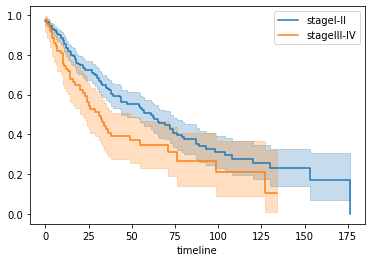

In [11]:
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()

kmf.fit(T12, event_observed=E12, label='stageI-II')
ax = kmf.plot()

kmf.fit(T34, event_observed=E34, label='stageIII-IV')
ax = kmf.plot()

In [ ]:
from lifelines.datasets import load_waltons
df = load_waltons()

In [ ]:
df

In [ ]:
T = df['T']
E = df['E']

In [ ]:
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()
kmf.fit(T, event_observed=E)

In [ ]:
kmf.survival_function_
kmf.cumulative_density_
kmf.plot_survival_function()

In [ ]:
kmf.plot_cumulative_density()

In [ ]:
T

In [ ]:
E

In [ ]:
df

In [ ]:
groups = df['group']

In [ ]:
groups

In [ ]:
ix = (groups == 'miR-137')

In [ ]:
ix

In [ ]:
groups == 'miR-137'

In [ ]:
kmf.fit(df.loc[df['group'] == 'control', 'T'], df.loc[df['group'] == 'control', 'E'], label='control')
ax = kmf.plot()

kmf.fit(df.loc[df['group'] == 'miR-137', 'T'], df.loc[df['group'] == 'miR-137', 'E'], label='miR-137')
ax = kmf.plot(ax=ax)

In [ ]:
df.loc[df['E'] == 0]

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_table('clinical.tsv')

In [ ]:
df

In [ ]:
Ta = df.loc[df['vital_status'] == 'Alive' , 'days_to_last_follow_up']

In [ ]:
Ta

In [ ]:
Td = df.loc[df['vital_status'] == 'Dead', 'days_to_death']

In [ ]:
Td

In [ ]:
T = pd.concat([Ta, Td])

In [ ]:
T

In [ ]:
df.loc[df['vital_status'] == 'Alive', 'vital_status'] = 0
df.loc[df['vital_status'] == 'Dead', 'vital_status'] = 1

In [ ]:
Ea = df.loc[df['vital_status'] == 0, 'vital_status']
Ed = df.loc[df['vital_status'] == 1, 'vital_status']

In [ ]:
Ea

In [ ]:
Ed

In [ ]:
E = pd.concat([Ea, Ed])

In [ ]:
E

In [ ]:
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()
kmf.fit(T, event_observed = E)

In [ ]:
T.to_csv('T.txt', sep='\t')

In [ ]:
E.to_csv('E.txt', sep='\t')